# 01 – Exploratory Data Analysis (Raw Data)
**PhishGuard URL · EATC Assignment 2 · 2026**

EDA is performed on the **raw, uncleaned** dataset so we understand what we are working with
before making any preprocessing decisions.

Figures are saved to `../reports/`.

> Dataset: URL-Phish v2 — DOI 10.17632/65z9twcx3r.2 (CC BY 4.0)  
> Place the CSV at `../data/Dataset.csv` before running.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('../reports', exist_ok=True)
sns.set_theme(style='darkgrid', palette='muted')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Raw Dataset

In [2]:
DATA_PATH = '../data/Dataset.csv'
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape: (116600, 26)
Columns: ['url', 'url_len', 'dom', 'dom_len', 'is_ip', 'tld', 'tld_len', 'subdom_cnt', 'letter_cnt', 'digit_cnt', 'special_cnt', 'eq_cnt', 'qm_cnt', 'amp_cnt', 'dot_cnt', 'dash_cnt', 'under_cnt', 'letter_ratio', 'digit_ratio', 'spec_ratio', 'is_https', 'slash_cnt', 'entropy', 'path_len', 'query_len', 'label']


,url,url_len,dom,dom_len,is_ip,tld,tld_len,subdom_cnt,letter_cnt,digit_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
0,https://www.rmit.edu.au/,24,rmit.edu.au,11,0,edu.au,6,1,17,0,...,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0
1,http://www.latrobe.edu.au/,26,latrobe.edu.au,14,0,edu.au,6,1,19,0,...,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0
2,https://www.cqu.edu.au/,23,cqu.edu.au,10,0,edu.au,6,1,16,0,...,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0


## 2. Dataset Overview

In [3]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Basic Statistics (numeric columns) ===')
df.describe().round(4)

=== Data Types ===
url              object
url_len           int64
dom              object
dom_len           int64
is_ip             int64
tld              object
tld_len           int64
subdom_cnt        int64
letter_cnt        int64
digit_cnt         int64
special_cnt       int64
eq_cnt            int64
qm_cnt            int64
amp_cnt           int64
dot_cnt           int64
dash_cnt          int64
under_cnt         int64
letter_ratio    float64
digit_ratio     float64
spec_ratio      float64
is_https          int64
slash_cnt         int64
entropy         float64
path_len          int64
query_len         int64
label             int64
dtype: object

=== Basic Statistics (numeric columns) ===


,url_len,dom_len,is_ip,tld_len,subdom_cnt,letter_cnt,digit_cnt,special_cnt,eq_cnt,qm_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
count,116600.0000,116600.0000,116600.0000,116600.0000,116600.0000,116600.0000,116600.0000,116600.0000,116600.0000,116600.0000,...,116600.0000,116600.0000,116600.0000,116600.0000,116600.0000,116600.0000,116600.0000,116600.0000,116600.0000,116600.0000
mean,32.9525,12.8458,0.0001,3.3202,0.8457,25.0068,0.9440,7.0017,0.0795,0.0384,...,0.0538,0.7525,0.0131,0.2344,0.4311,3.2150,3.8637,6.3914,1.6006,0.1424
std,29.3700,5.1407,0.0106,1.4182,0.4806,22.3964,5.9477,3.9958,0.4926,0.1999,...,0.4837,0.0591,0.0477,0.0529,0.4952,0.9305,0.3596,17.5891,19.2737,0.3494
min,12.0000,4.0000,0.0000,0.0000,0.0000,4.0000,0.0000,4.0000,0.0000,0.0000,...,0.0000,0.1449,0.0000,0.0130,0.0000,2.0000,2.6535,0.0000,0.0000,0.0000
25%,22.0000,9.0000,0.0000,2.0000,1.0000,16.0000,0.0000,6.0000,0.0000,0.0000,...,0.0000,0.7143,0.0000,0.1944,0.0000,3.0000,3.6425,1.0000,0.0000,0.0000
50%,27.0000,11.0000,0.0000,3.0000,1.0000,20.0000,0.0000,6.0000,0.0000,0.0000,...,0.0000,0.7500,0.0000,0.2368,0.0000,3.0000,3.8314,1.0000,0.0000,0.0000
75%,34.0000,16.0000,0.0000,3.0000,1.0000,27.0000,0.0000,7.0000,0.0000,0.0000,...,0.0000,0.7931,0.0000,0.2727,1.0000,3.0000,4.0272,4.0000,0.0000,0.0000
max,1202.0000,62.0000,1.0000,22.0000,7.0000,1037.0000,321.0000,234.0000,29.0000,17.0000,...,20.0000,0.9360,0.8261,0.5238,1.0000,37.0000,6.0327,670.0000,1148.0000,1.0000


## 3. Class Distribution

Label 0 (Legitimate): 100,000
Label 1 (Phishing):   16,600
Phishing prevalence:  14.24%


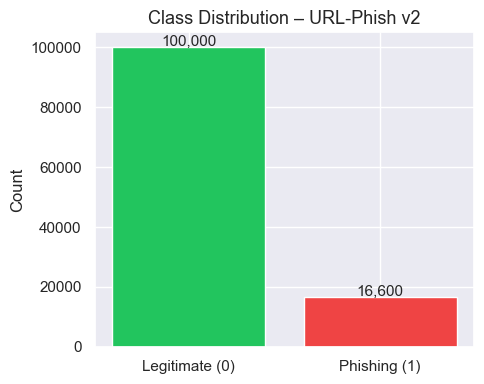

Saved: reports/fig_class_distribution.png


In [4]:
vc = df['label'].value_counts().sort_index()
print(f'Label 0 (Legitimate): {vc.get(0, 0):,}')
print(f'Label 1 (Phishing):   {vc.get(1, 0):,}')
print(f'Phishing prevalence:  {vc.get(1,0)/len(df)*100:.2f}%')

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Legitimate (0)', 'Phishing (1)'],
              [vc.get(0,0), vc.get(1,0)],
              color=['#22c55e', '#ef4444'])
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{int(bar.get_height()):,}', ha='center', fontsize=11)
ax.set_title('Class Distribution – URL-Phish v2', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/fig_class_distribution.png', dpi=150)
plt.show()
print('Saved: reports/fig_class_distribution.png')

## 4. Missing Values

In [5]:
FEATURE_NAMES = [
    'url_len','dom_len','is_ip','tld_len','subdom_cnt',
    'letter_cnt','digit_cnt','special_cnt','eq_cnt','qm_cnt',
    'amp_cnt','dot_cnt','dash_cnt','under_cnt','letter_ratio',
    'digit_ratio','spec_ratio','is_https','slash_cnt','entropy',
    'path_len','query_len'
]
feature_cols = [c for c in FEATURE_NAMES if c in df.columns]
missing = df[feature_cols].isnull().sum()
print('Missing values in feature columns:')
print(missing[missing > 0] if missing.sum() > 0 else 'None — all features complete')

Missing values in feature columns:
None — all features complete


## 5. Duplicate Check

In [6]:
if 'url' in df.columns:
    n_dupes = df.duplicated(subset=['url']).sum()
    print(f'Exact URL duplicates:  {n_dupes:,}')
    print(f'Unique URLs:           {df["url"].nunique():,}')
    conflicts = df.groupby('url')['label'].nunique()
    print(f'Conflicting labels:    {(conflicts > 1).sum()}')
else:
    print('No url column – skipping duplicate check')

Exact URL duplicates:  1,369
Unique URLs:           115,231
Conflicting labels:    0


## 6. Feature Distributions by Class

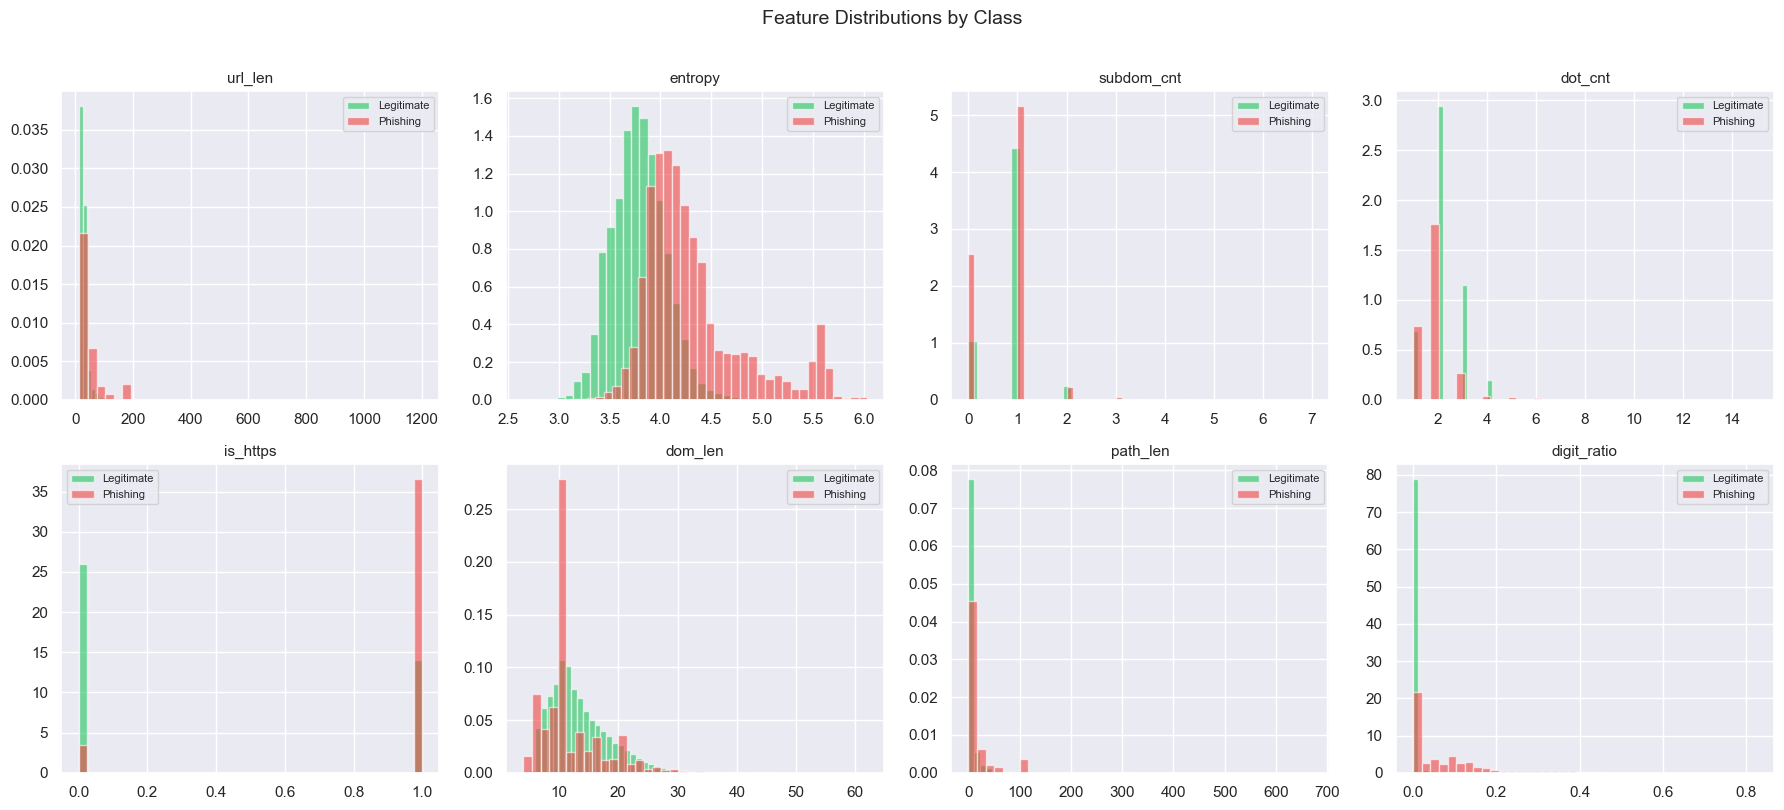

Saved: reports/fig_feature_distributions.png


In [7]:
key_features = [
    'url_len','entropy','subdom_cnt','dot_cnt',
    'is_https','dom_len','path_len','digit_ratio'
]
plot_cols = [c for c in key_features if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(plot_cols):
    for label, color, name in [(0,'#22c55e','Legitimate'),(1,'#ef4444','Phishing')]:
        axes[i].hist(df[df['label']==label][feat], bins=40,
                     alpha=0.6, color=color, label=name, density=True)
    axes[i].set_title(feat, fontsize=11)
    axes[i].legend(fontsize=8)
plt.suptitle('Feature Distributions by Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/fig_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/fig_feature_distributions.png')

## 7. Correlation Heatmap

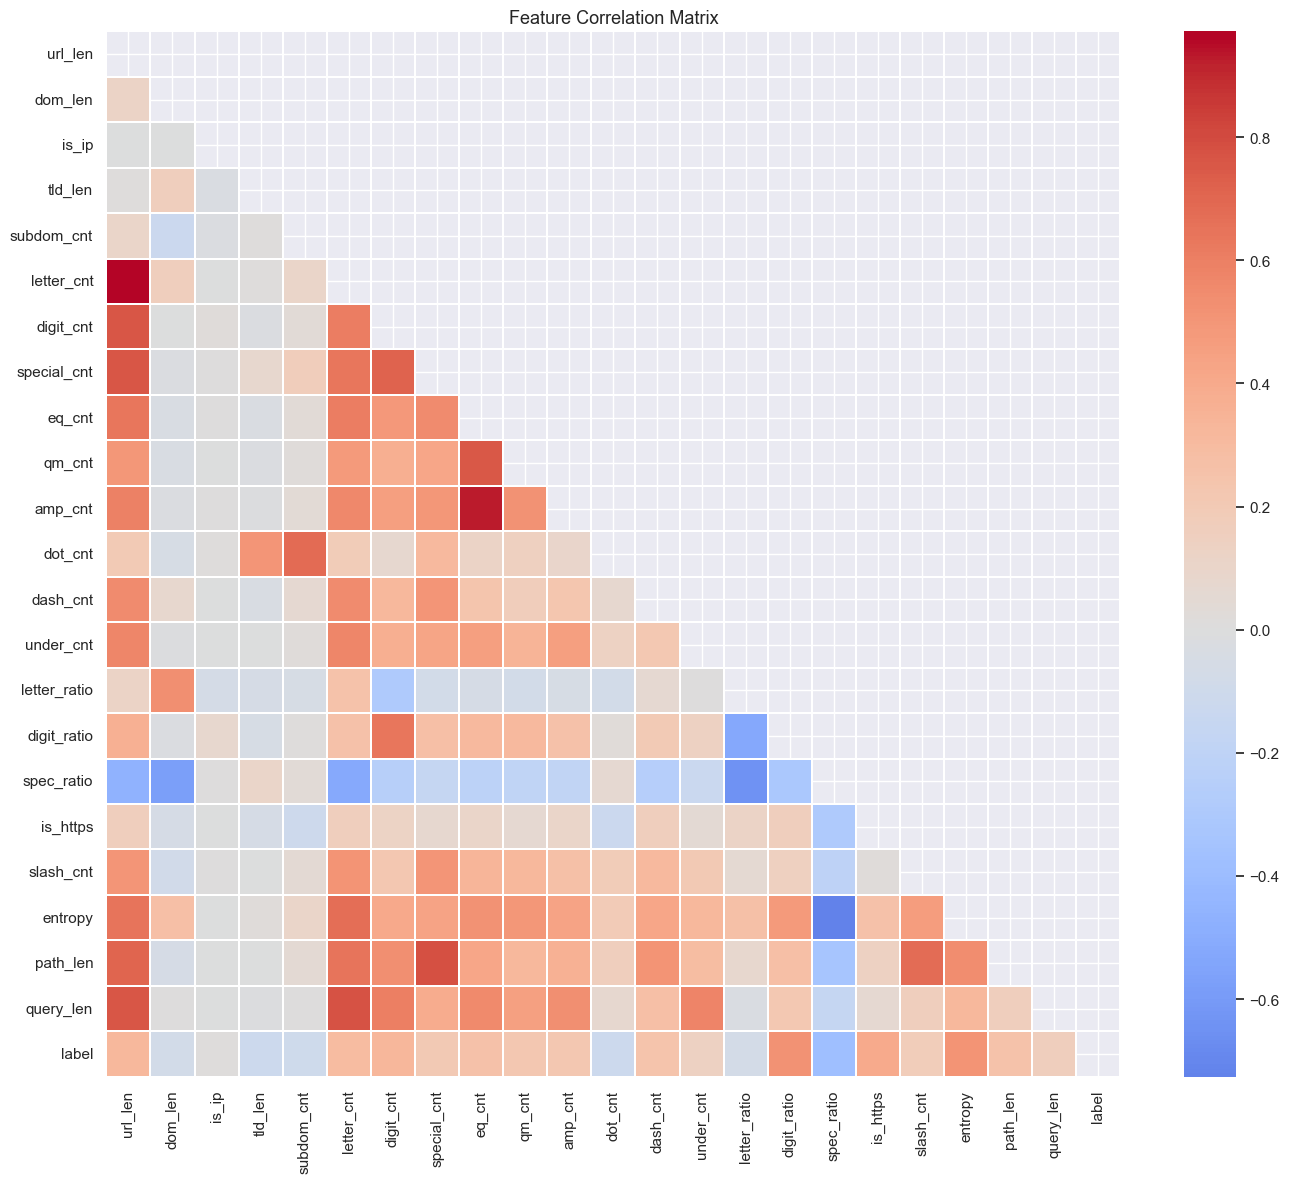

Saved: reports/fig_correlation_heatmap.png


In [8]:
corr_cols = [c for c in feature_cols + ['label'] if c in df.columns]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/fig_correlation_heatmap.png', dpi=150)
plt.show()
print('Saved: reports/fig_correlation_heatmap.png')

## 8. Top Correlations with Label

Top 10 features by |correlation with label|:
digit_ratio    0.5178
entropy        0.5127
is_https       0.3975
spec_ratio    -0.3846
digit_cnt      0.3295
url_len        0.3240
letter_cnt     0.3010
eq_cnt         0.2612
path_len       0.2493
dash_cnt       0.2481
Name: label, dtype: float64


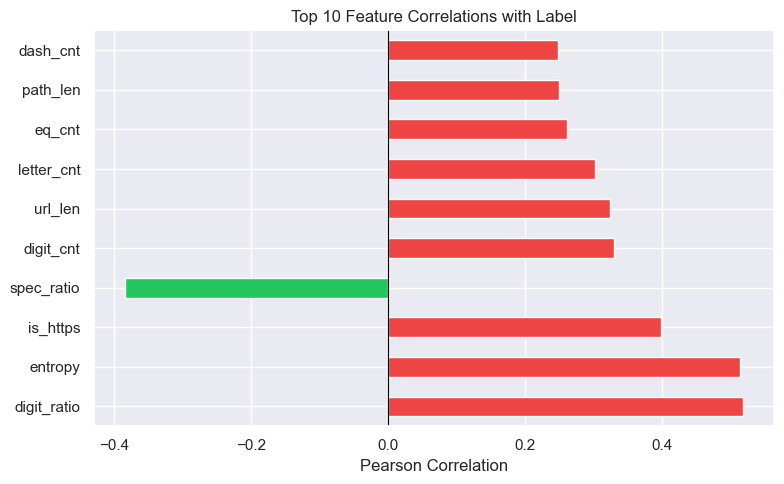

Saved: reports/fig_label_correlations.png


In [9]:
label_corr = corr['label'].drop('label').sort_values(key=abs, ascending=False)
print('Top 10 features by |correlation with label|:')
print(label_corr.head(10).round(4))

fig, ax = plt.subplots(figsize=(8, 5))
label_corr.head(10).plot(kind='barh', ax=ax,
    color=['#ef4444' if v>0 else '#22c55e' for v in label_corr.head(10)])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 10 Feature Correlations with Label', fontsize=12)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('../reports/fig_label_correlations.png', dpi=150)
plt.show()
print('Saved: reports/fig_label_correlations.png')

## 9. EDA Summary

Key findings from the raw data:
- Class distribution is **imbalanced** (~14% phishing) — handled by stratified splitting and class weights.
- No missing values in any feature column.
- There are **duplicate URLs** (same URL, same label) that will be removed in preprocessing.
- `is_https`, `entropy`, `url_len`, and `dom_len` show the strongest separation between classes.
- Some features are mathematically related (count vs ratio pairs) — tree models handle this naturally.

Proceed to `02_preprocessing.ipynb`.